# YCbCr Banana Ripeness Classification

This notebook implements the YCbCr image-processing pipeline for banana ripeness assessment. The workflow is: resize → Gaussian filtering → YCbCr conversion → gamma correction on Y → Cb–Cr segmentation → morphology → banana-region extraction → normalized Cb/Cr histogram features → `StandardScaler()` → default `SVC()`.

## 1. Imports

The required image-processing, data-analysis, visualization, and classification libraries are imported below.

In [1]:
from pathlib import Path
from datetime import datetime
import time
import json

import cv2
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)

np.random.seed(42)
pd.set_option("display.max_columns", 20)
plt.rcParams.update({"figure.figsize": (10, 5), "axes.grid": False})
print("Imports complete.")


Imports complete.


## 2. Experiment Configuration

The experiment uses 416 × 416 images, a 3 × 3 Gaussian filter, gamma correction on the Y channel, fixed Cb–Cr peel-colour ranges, morphological cleaning, 32-bin Cb and Cr histograms, and the original train/validation/test split. The final parameters were selected using training and validation data before final testing.

In [2]:
DATASET_DIR = Path(r"C:\Users\ASUS\Documents\Banana\Banana Ripeness Classification Dataset")
IMAGE_SIZE = (416, 416)
GAUSSIAN_KERNEL = (3, 3)
CLASS_ORDER = ["overripe", "ripe", "rotten", "unripe"]
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

CURRENT_GREEN_PEEL_RANGE = {
    "name": "green_peel_current", "cb_min": 80, "cb_max": 125,
    "cr_min": 90, "cr_max": 124,
}
PROPOSED_GREEN_PEEL_RANGE = {
    "name": "green_peel", "cb_min": 80, "cb_max": 125,
    "cr_min": 90, "cr_max": 132,
}
UNCHANGED_NON_GREEN_RANGES = [
    {"name": "yellow_peel",     "cb_min": 45,  "cb_max": 115, "cr_min": 130, "cr_max": 190},
    {"name": "brown_peel",      "cb_min": 80,  "cb_max": 125, "cr_min": 135, "cr_max": 185},
    {"name": "dark_brown_peel", "cb_min": 105, "cb_max": 130, "cr_min": 130, "cr_max": 165},
]
CURRENT_CBCR_RANGES = [CURRENT_GREEN_PEEL_RANGE, *UNCHANGED_NON_GREEN_RANGES]
CANDIDATE_CBCR_RANGES = [PROPOSED_GREEN_PEEL_RANGE, *UNCHANGED_NON_GREEN_RANGES]

GAMMA = 0.90
HIST_BINS = 32
MORPH_KERNEL_SIZE = 5
MORPH_ITERATIONS = 1
PARAMETERS_FROZEN = True

OUTPUT_ROOT = Path("results")
# A fresh results directory is created only when Section 22 is executed.

print("GAMMA:", GAMMA, "| HIST_BINS:", HIST_BINS)
print("Current vs proposed green range (only Cr maximum changes):")
display(pd.DataFrame([CURRENT_GREEN_PEEL_RANGE, PROPOSED_GREEN_PEEL_RANGE]))
print("Unchanged non-green ranges:")
display(pd.DataFrame(UNCHANGED_NON_GREEN_RANGES))
print("PARAMETERS_FROZEN:", PARAMETERS_FROZEN)


GAMMA: 0.9 | HIST_BINS: 32
Current vs proposed green range (only Cr maximum changes):
Unchanged non-green ranges:
PARAMETERS_FROZEN: True


,name,cb_min,cb_max,cr_min,cr_max
0,green_peel_current,80,125,90,124
1,green_peel,80,125,90,132


,name,cb_min,cb_max,cr_min,cr_max
0,yellow_peel,45,115,130,190
1,brown_peel,80,125,135,185
2,dark_brown_peel,105,130,130,165


### Image Preprocessing Strategy

| Image Problem | Preprocessing Approach | Selected Technique |
|---|---|---|
| Image noise | Noise reduction | 3 × 3 Gaussian filtering |
| Lighting variation and overexposure | Illumination correction | Gamma correction on the Y channel |
| Background variation | Banana region segmentation | Fixed Cb–Cr colour thresholding with morphological refinement |
| Colour similarity between ripeness stages | Colour feature extraction | Normalized Cb and Cr histogram features |

**Final pipeline:** Input Image → Resize to 416 × 416 → Gaussian Filtering → RGB-to-YCbCr Conversion → Gamma Correction on Y → Cb–Cr Colour Segmentation → Morphological Refinement → Banana Region Extraction → Cb and Cr Histogram Features → StandardScaler → SVC → Ripeness Classification


## 3. Dataset Loading and Verification

The existing split is preserved. The validation directory is detected as `valid`, `validation`, or `val`; no images are downloaded or redistributed.

In [3]:
def detect_subset_dirs(dataset_dir):
    if not dataset_dir.exists():
        raise FileNotFoundError(f"Dataset directory not found: {dataset_dir}")
    train_dir = dataset_dir / "train"
    test_dir = dataset_dir / "test"
    val_candidates = [dataset_dir / name for name in ("valid", "validation", "val")]
    val_matches = [p for p in val_candidates if p.is_dir()]
    if not train_dir.is_dir() or not test_dir.is_dir() or not val_matches:
        raise FileNotFoundError("Expected train, test, and valid/validation/val directories.")
    return {"train": train_dir, "validation": val_matches[0], "test": test_dir}

def discover_images(subset_dirs):
    rows = []
    for subset in ("train", "validation", "test"):
        subset_dir = subset_dirs[subset]
        found_classes = sorted(p.name for p in subset_dir.iterdir() if p.is_dir())
        missing = sorted(set(CLASS_ORDER) - set(found_classes))
        extra = sorted(set(found_classes) - set(CLASS_ORDER))
        if missing or extra:
            raise ValueError(f"{subset}: missing={missing}, unexpected={extra}")
        for label in CLASS_ORDER:
            paths = sorted(
                (p for p in (subset_dir / label).rglob("*")
                 if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS),
                key=lambda p: str(p).lower(),
            )
            rows.extend({"image_path": str(p), "subset": subset, "true_class": label} for p in paths)
    return pd.DataFrame(rows)

SUBSET_DIRS = detect_subset_dirs(DATASET_DIR)
image_index = discover_images(SUBSET_DIRS)
print("Detected directories:", SUBSET_DIRS)
print("Indexed images:", len(image_index))


Detected directories: {'train': WindowsPath('C:/Users/ASUS/Documents/Banana/Banana Ripeness Classification Dataset/train'), 'validation': WindowsPath('C:/Users/ASUS/Documents/Banana/Banana Ripeness Classification Dataset/valid'), 'test': WindowsPath('C:/Users/ASUS/Documents/Banana/Banana Ripeness Classification Dataset/test')}
Indexed images: 13478


## 4. Dataset Distribution

Counts are shown in the same class order for train, validation, and test.

In [4]:
dataset_counts = (
    image_index.groupby(["subset", "true_class"], observed=False)
    .size().rename("image_count").reset_index()
)
count_table = dataset_counts.pivot(index="true_class", columns="subset", values="image_count")
count_table = count_table.reindex(index=CLASS_ORDER, columns=["train", "validation", "test"]).fillna(0).astype(int)
display(count_table)


subset,train,validation,test
true_class,,,
overripe,2349,229,113
ripe,3522,339,154
rotten,4020,388,185
unripe,1902,167,110


## 5. Reusable Image-Processing Functions

OpenCV calls the colour space `YCrCb` and returns channels in **Y, Cr, Cb** order. The function below explicitly returns `Y, Cb, Cr` to prevent accidental channel reversal. Gamma correction affects Y only; the original Cb and Cr are retained.

In [3]:
def load_image(path):
    bgr = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if bgr is None:
        raise ValueError("OpenCV could not decode the image")
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

def resize_image(rgb, image_size=IMAGE_SIZE):
    if (rgb.shape[1], rgb.shape[0]) == image_size:
        return rgb
    return cv2.resize(rgb, image_size, interpolation=cv2.INTER_AREA)

def apply_gaussian_filter(rgb):
    return cv2.GaussianBlur(rgb, GAUSSIAN_KERNEL, 0)

def convert_to_ycbcr(rgb):
    ycrcb = cv2.cvtColor(rgb, cv2.COLOR_RGB2YCrCb)
    Y, Cr, Cb = cv2.split(ycrcb)
    return Y, Cb, Cr

def gamma_correct_y(Y, gamma=GAMMA):
    if gamma <= 0:
        raise ValueError("GAMMA must be positive")
    lut = np.clip(255.0 * (np.arange(256, dtype=np.float32) / 255.0) ** gamma, 0, 255).astype(np.uint8)
    return cv2.LUT(Y, lut)

def reconstruct_rgb(corrected_Y, Cb, Cr):
    ycrcb = cv2.merge([corrected_Y, Cr, Cb])
    return cv2.cvtColor(ycrcb, cv2.COLOR_YCrCb2RGB)

def create_cbcr_mask(Cb, Cr, ranges=CANDIDATE_CBCR_RANGES):
    """OR-combine fixed Cb–Cr rectangles; no class label is accepted or used."""
    selected = np.zeros(Cb.shape, dtype=bool)
    for bounds in ranges:
        selected |= (
            (Cb >= bounds["cb_min"]) & (Cb <= bounds["cb_max"]) &
            (Cr >= bounds["cr_min"]) & (Cr <= bounds["cr_max"])
        )
    return selected.astype(np.uint8) * 255

def clean_mask(mask):
    kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE, (MORPH_KERNEL_SIZE, MORPH_KERNEL_SIZE)
    )
    opened = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=MORPH_ITERATIONS)
    return cv2.morphologyEx(opened, cv2.MORPH_CLOSE, kernel, iterations=MORPH_ITERATIONS)

def extract_banana_region(rgb, mask):
    return cv2.bitwise_and(rgb, rgb, mask=mask)

def normalized_histogram(channel, mask, bins=HIST_BINS):
    pixels = channel[mask > 0]
    if pixels.size == 0:
        return np.zeros(bins, dtype=np.float32)
    hist, _ = np.histogram(pixels, bins=bins, range=(0, 256))
    hist = hist.astype(np.float32)
    total = hist.sum()
    return hist / total if total > 0 else np.zeros(bins, dtype=np.float32)

def extract_cbcr_histograms(Cb, Cr, mask):
    return np.concatenate([
        normalized_histogram(Cb, mask), normalized_histogram(Cr, mask)
    ])

def feature_names(bins=HIST_BINS):
    return ([f"cb_bin_{i:02d}" for i in range(bins)] +
            [f"cr_bin_{i:02d}" for i in range(bins)])


## 6. Gaussian Filtering Demonstration

This training example compares the resized original with the 3 × 3 Gaussian-filtered image.

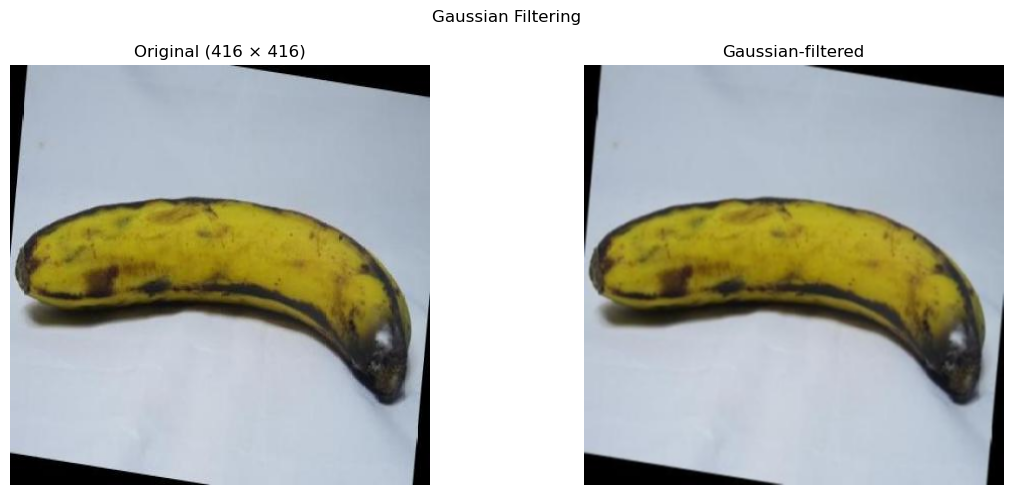

In [6]:
DEMO_PATH = Path(image_index.query("subset == 'train'").iloc[0]["image_path"])
demo_original = resize_image(load_image(DEMO_PATH))
demo_filtered = apply_gaussian_filter(demo_original)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, image, title in zip(axes, [demo_original, demo_filtered], ["Original (416 × 416)", "Gaussian-filtered"]):
    ax.imshow(image); ax.set_title(title); ax.axis("off")
fig.suptitle("Gaussian Filtering")
plt.tight_layout()
plt.show()


## 7. YCbCr Conversion Demonstration

The displayed channel labels use the conceptual Y, Cb, Cr order even though OpenCV stores Y, Cr, Cb.

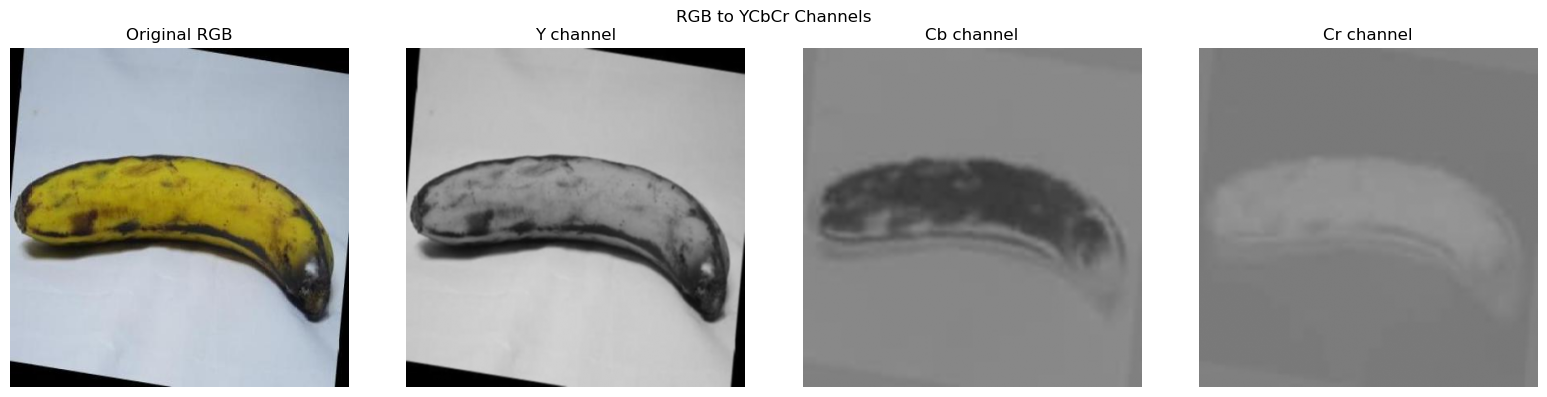

In [7]:
demo_Y, demo_Cb, demo_Cr = convert_to_ycbcr(demo_filtered)
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(demo_original); axes[0].set_title("Original RGB")
for ax, channel, title in zip(axes[1:], [demo_Y, demo_Cb, demo_Cr], ["Y channel", "Cb channel", "Cr channel"]):
    ax.imshow(channel, cmap="gray", vmin=0, vmax=255); ax.set_title(title)
for ax in axes: ax.axis("off")
fig.suptitle("RGB to YCbCr Channels")
plt.tight_layout(); plt.show()


## 8. Gamma Correction on Y

Gamma correction is applied only to Y. It can reduce ordinary illumination variation, but it **cannot recover colour information destroyed by severe overexposure**.

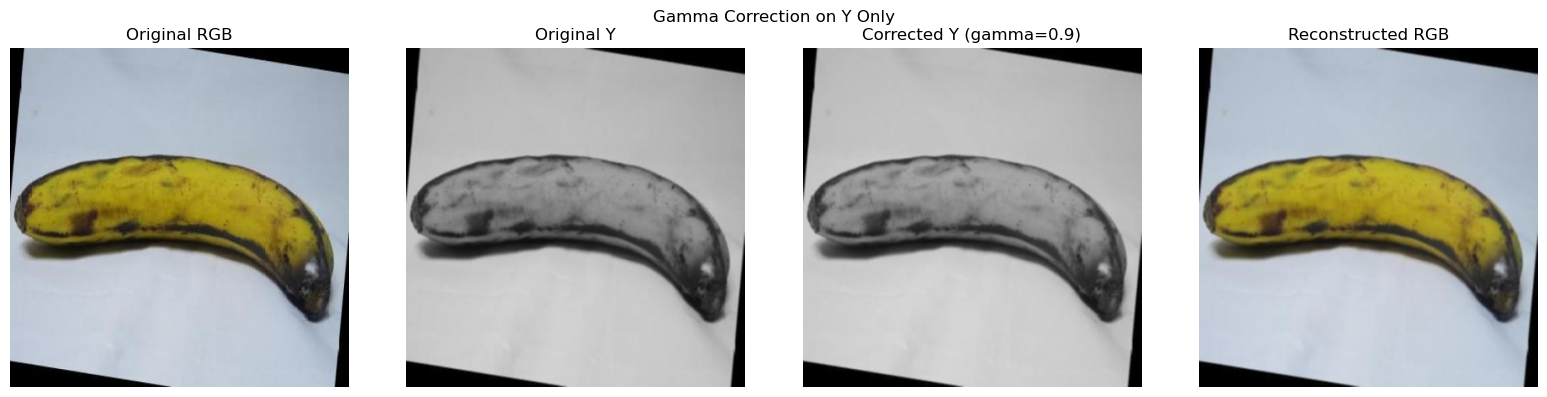

In [8]:
demo_Y_corrected = gamma_correct_y(demo_Y)
demo_reconstructed = reconstruct_rgb(demo_Y_corrected, demo_Cb, demo_Cr)
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
items = [(demo_original, "Original RGB", None), (demo_Y, "Original Y", "gray"),
         (demo_Y_corrected, f"Corrected Y (gamma={GAMMA})", "gray"),
         (demo_reconstructed, "Reconstructed RGB", None)]
for ax, (image, title, cmap) in zip(axes, items):
    ax.imshow(image, cmap=cmap, vmin=0 if cmap else None, vmax=255 if cmap else None)
    ax.set_title(title); ax.axis("off")
fig.suptitle("Gamma Correction on Y Only")
plt.tight_layout(); plt.show()


## 9. Cb–Cr Segmentation and Morphological Refinement

The fixed Cb–Cr ranges are combined into one binary mask. Morphological opening removes small isolated regions, while closing fills small gaps before the banana region is extracted.

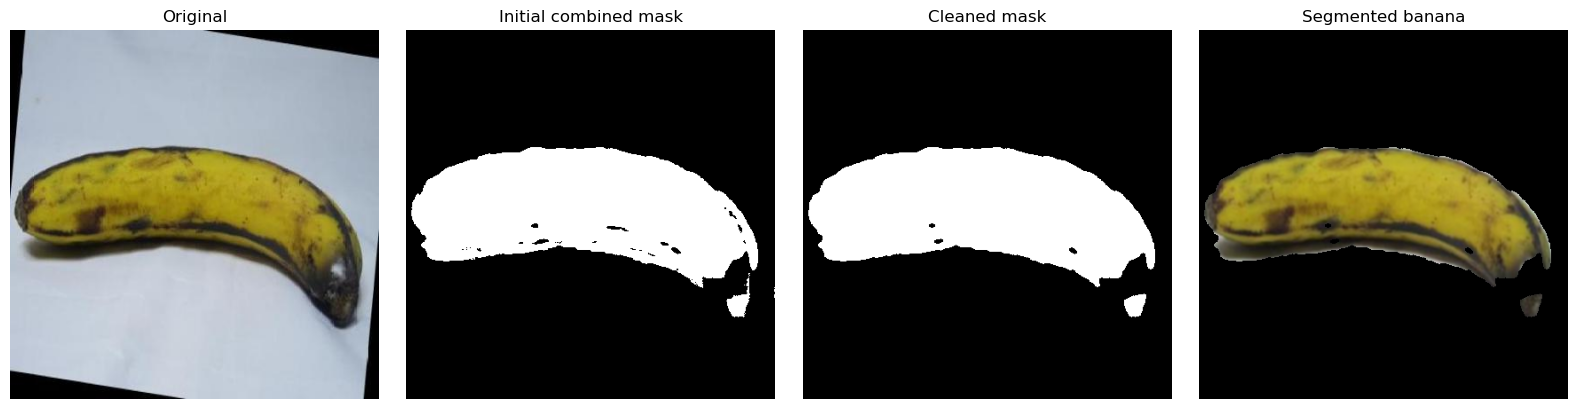

In [9]:
def preprocessing_intermediates(path, ranges=CANDIDATE_CBCR_RANGES):
    original = resize_image(load_image(path))
    filtered = apply_gaussian_filter(original)
    Y, Cb, Cr = convert_to_ycbcr(filtered)
    corrected_Y = gamma_correct_y(Y)
    corrected_rgb = reconstruct_rgb(corrected_Y, Cb, Cr)
    initial_mask = create_cbcr_mask(Cb, Cr, ranges=ranges)
    final_mask = clean_mask(initial_mask)
    segmented = extract_banana_region(corrected_rgb, final_mask)
    return original, filtered, Y, corrected_Y, Cb, Cr, corrected_rgb, initial_mask, final_mask, segmented

demo = preprocessing_intermediates(DEMO_PATH)
_, _, _, _, _, _, _, demo_initial_mask, demo_final_mask, demo_segmented = demo
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, image, title, cmap in zip(
    axes, [demo_original, demo_initial_mask, demo_final_mask, demo_segmented],
    ["Original", "Initial combined mask", "Cleaned mask", "Segmented banana"],
    [None, "gray", "gray", None]
):
    ax.imshow(image, cmap=cmap); ax.set_title(title); ax.axis("off")
plt.tight_layout(); plt.show()


## 10. Sample Input and Output by Ripeness Class

The figure below shows one representative image from each ripeness class processed using the same final frozen YCbCr segmentation settings. Each row presents the original input, final cleaned Cb–Cr mask, and segmented output.


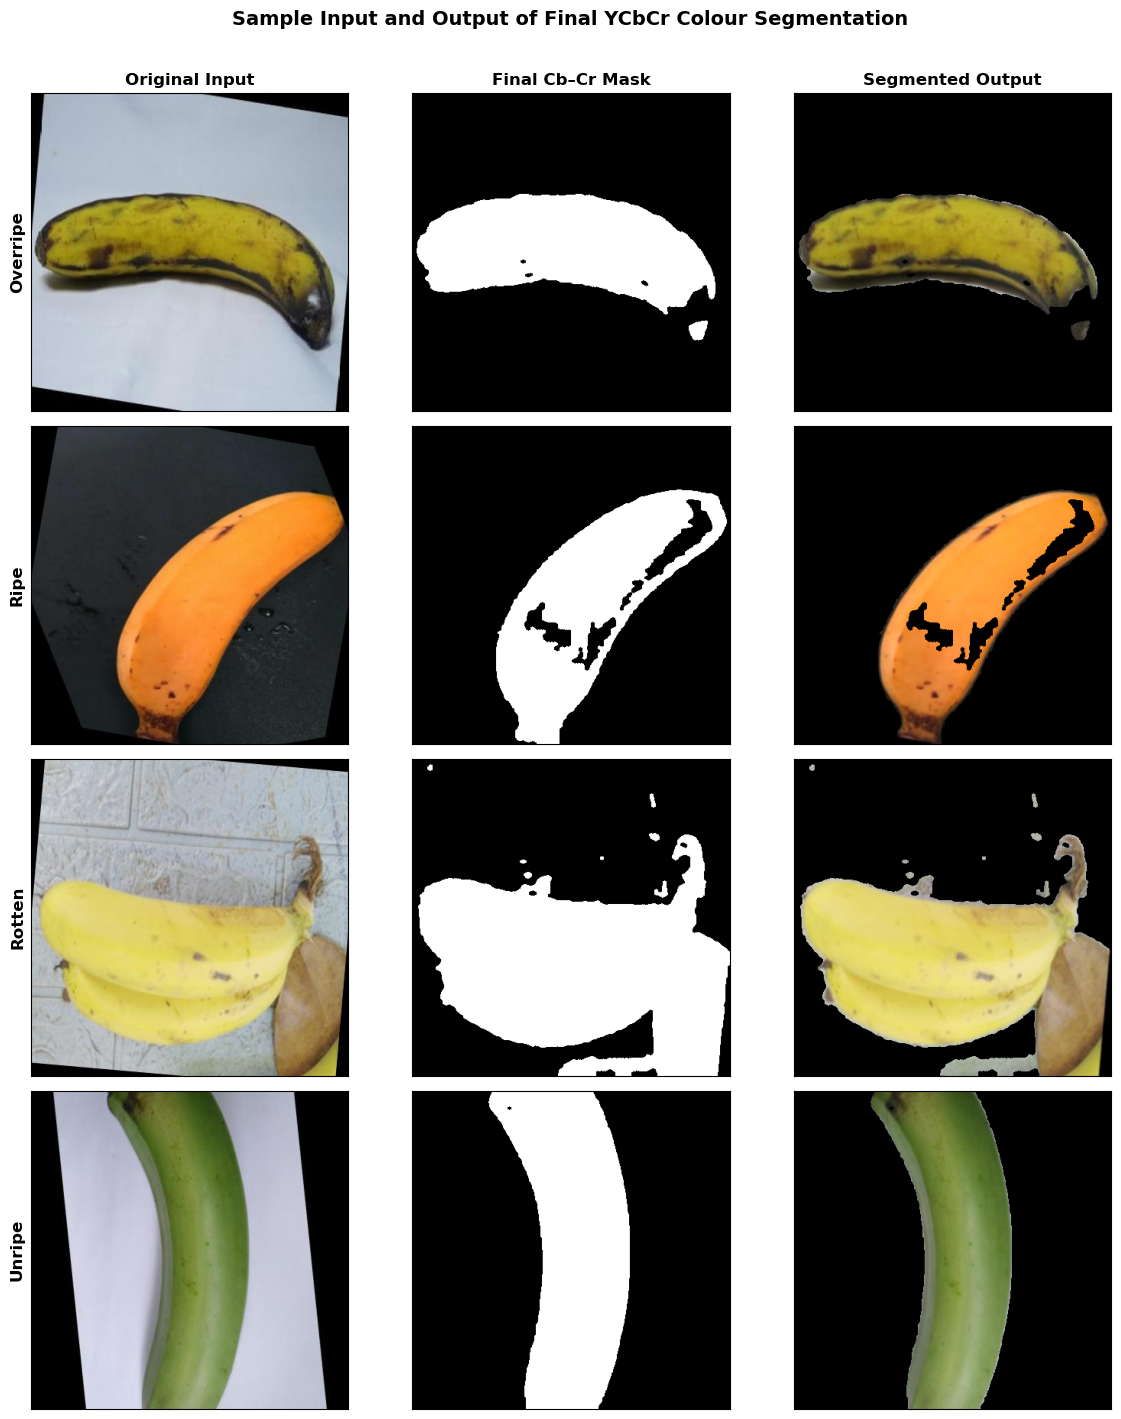

In [10]:
sample_rows = []
for label in CLASS_ORDER:
    sample_path = Path(image_index.query("subset == 'train' and true_class == @label").iloc[0]["image_path"])
    original, _, _, _, _, _, _, _, final_mask, segmented = preprocessing_intermediates(sample_path)
    sample_rows.append((label, original, final_mask, segmented))

fig, axes = plt.subplots(len(sample_rows), 3, figsize=(12, 14))
column_titles = ["Original Input", "Final Cb–Cr Mask", "Segmented Output"]

for col, title in enumerate(column_titles):
    axes[0, col].set_title(title, fontsize=12, fontweight="bold")

for row, (label, original, final_mask, segmented) in enumerate(sample_rows):
    axes[row, 0].imshow(original)
    axes[row, 1].imshow(final_mask, cmap="gray", vmin=0, vmax=255)
    axes[row, 2].imshow(segmented)

    axes[row, 0].set_ylabel(label.capitalize(), fontsize=12, fontweight="bold")

    for col in range(3):
        axes[row, col].set_xticks([])
        axes[row, col].set_yticks([])

fig.suptitle("Sample Input and Output of Final YCbCr Colour Segmentation",
             fontsize=14, fontweight="bold", y=1.01)

plt.tight_layout()
plt.show()

## 11. Cb and Cr Histogram Features

Only pixels inside the cleaned banana mask are used. Separate normalized Cb and Cr histograms are concatenated to form a 64-feature vector for each image.

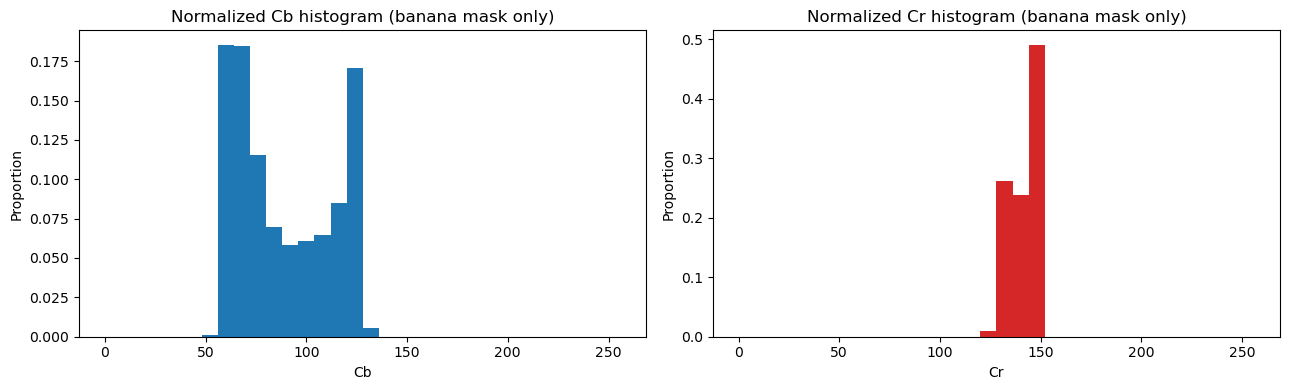

Feature length: 64 Expected: 64


In [11]:
_, _, _, _, demo_Cb, demo_Cr, _, _, demo_mask, _ = demo
demo_features = extract_cbcr_histograms(demo_Cb, demo_Cr, demo_mask)
edges = np.linspace(0, 256, HIST_BINS + 1)
centres = (edges[:-1] + edges[1:]) / 2
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(centres, demo_features[:HIST_BINS], width=256/HIST_BINS)
axes[0].set(title="Normalized Cb histogram (banana mask only)", xlabel="Cb", ylabel="Proportion")
axes[1].bar(centres, demo_features[HIST_BINS:], width=256/HIST_BINS, color="tab:red")
axes[1].set(title="Normalized Cr histogram (banana mask only)", xlabel="Cr", ylabel="Proportion")
plt.tight_layout(); plt.show()
print("Feature length:", len(demo_features), "Expected:", 2 * HIST_BINS)


## 12. Final YCbCr Parameters

The final fixed image-processing settings used for the complete experiment are recorded below.

In [4]:
frozen_parameters = {
    "IMAGE_SIZE": list(IMAGE_SIZE), "GAUSSIAN_KERNEL": list(GAUSSIAN_KERNEL),
    "GAMMA": GAMMA, "CANDIDATE_CBCR_RANGES": CANDIDATE_CBCR_RANGES,
    "HIST_BINS": HIST_BINS, "MORPH_KERNEL_SIZE": MORPH_KERNEL_SIZE,
    "MORPH_ITERATIONS": MORPH_ITERATIONS, "CLASS_ORDER": CLASS_ORDER,
}
display(pd.Series(frozen_parameters, name="frozen_value"))


IMAGE_SIZE                                                      [416, 416]
GAUSSIAN_KERNEL                                                     [3, 3]
GAMMA                                                                  0.9
CANDIDATE_CBCR_RANGES    [{'name': 'green_peel', 'cb_min': 80, 'cb_max'...
HIST_BINS                                                               32
MORPH_KERNEL_SIZE                                                        5
MORPH_ITERATIONS                                                         1
CLASS_ORDER                               [overripe, ripe, rotten, unripe]
Name: frozen_value, dtype: object

## 13. Full Dataset Processing

All images are processed using the fixed YCbCr pipeline. Processing time and segmentation status are recorded for each image.

In [13]:
def process_image(path):
    start = time.perf_counter()
    original = resize_image(load_image(path))
    filtered = apply_gaussian_filter(original)
    Y, Cb, Cr = convert_to_ycbcr(filtered)
    corrected_Y = gamma_correct_y(Y)
    initial_mask = create_cbcr_mask(Cb, Cr)
    final_mask = clean_mask(initial_mask)
    features = extract_cbcr_histograms(Cb, Cr, final_mask)
    elapsed = time.perf_counter() - start
    mask_pixels = int(np.count_nonzero(final_mask))
    status = "ok" if mask_pixels > 0 else "empty_mask"
    return features, elapsed, status, mask_pixels

def process_subset(index_df, subset, progress_every=500):
    rows = index_df[index_df.subset == subset].reset_index(drop=True)
    results, failures = [], []
    names = feature_names()
    for i, row in enumerate(rows.itertuples(index=False), start=1):
        try:
            features, elapsed, status, mask_pixels = process_image(row.image_path)
            record = {"image_path": row.image_path, "subset": subset, "true_class": row.true_class,
                      "processing_time_seconds": elapsed, "segmentation_status": status,
                      "mask_pixels": mask_pixels}
            record.update(dict(zip(names, features)))
            results.append(record)
            if status != "ok":
                failures.append({"image_path": row.image_path, "subset": subset,
                                 "true_class": row.true_class, "reason": status})
        except Exception as exc:
            failures.append({"image_path": row.image_path, "subset": subset,
                             "true_class": row.true_class, "reason": repr(exc)})
        if i % progress_every == 0 or i == len(rows):
            print(f"{subset}: processed {i} / {len(rows)} images")
    return pd.DataFrame(results), pd.DataFrame(failures)

processed, failure_frames = {}, []
for subset in ("train", "validation", "test"):
    processed[subset], subset_failures = process_subset(image_index, subset)
    failure_frames.append(subset_failures)
failed_images = pd.concat(failure_frames, ignore_index=True) if any(not x.empty for x in failure_frames) else pd.DataFrame(
    columns=["image_path", "subset", "true_class", "reason"]
)
print("Recorded failures/status issues:", len(failed_images))
display(failed_images.head())


train: processed 500 / 11793 images
train: processed 1000 / 11793 images
train: processed 1500 / 11793 images
train: processed 2000 / 11793 images
train: processed 2500 / 11793 images
train: processed 3000 / 11793 images
train: processed 3500 / 11793 images
train: processed 4000 / 11793 images
train: processed 4500 / 11793 images
train: processed 5000 / 11793 images
train: processed 5500 / 11793 images
train: processed 6000 / 11793 images
train: processed 6500 / 11793 images
train: processed 7000 / 11793 images
train: processed 7500 / 11793 images
train: processed 8000 / 11793 images
train: processed 8500 / 11793 images
train: processed 9000 / 11793 images
train: processed 9500 / 11793 images
train: processed 10000 / 11793 images
train: processed 10500 / 11793 images
train: processed 11000 / 11793 images
train: processed 11500 / 11793 images
train: processed 11793 / 11793 images
validation: processed 500 / 1123 images
validation: processed 1000 / 1123 images
validation: processed 1123 

,image_path,subset,true_class,reason


train: processed 5500 / 11793 images


train: processed 6000 / 11793 images


train: processed 6500 / 11793 images


...

validation: processed 1000 / 1123 images


validation: processed 1123 / 1123 images


test: processed 500 / 562 images


test: processed 562 / 562 images
Recorded failures/status issues: 0


,image_path,subset,true_class,reason


## 14. Feature Matrix Preparation

The extracted 64-dimensional feature vectors are converted into training, validation, and testing matrices. Feature length and finite values are verified before classification.

In [5]:
FEATURE_COLUMNS = feature_names()

def make_xy(df):
    X = df[FEATURE_COLUMNS].to_numpy(dtype=np.float32)
    y = df["true_class"].to_numpy()
    if X.ndim != 2 or X.shape[1] != 2 * HIST_BINS:
        raise ValueError(f"Unexpected feature shape: {X.shape}")
    if not np.isfinite(X).all():
        raise ValueError("NaN or infinity found in feature matrix")
    return X, y

X_train, y_train = make_xy(processed["train"])
X_val, y_val = make_xy(processed["validation"])
X_test, y_test = make_xy(processed["test"])
print("X_train, y_train:", X_train.shape, y_train.shape)
print("X_val, y_val:", X_val.shape, y_val.shape)
print("X_test, y_test:", X_test.shape, y_test.shape)


X_train, y_train: (11793, 64) (11793,)
X_val, y_val: (1123, 64) (1123,)
X_test, y_test: (562, 64) (562,)


## 15. Classification Model

The group-agreed classifier uses `StandardScaler()` followed by the default `SVC()` without hyperparameter tuning.

In [6]:
model = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC())
])
train_start = time.perf_counter()
model.fit(X_train, y_train)
validation_model_training_time = time.perf_counter() - train_start
print(f"Validation model training time: {validation_model_training_time:.3f} seconds")


Validation model training time: 2.754 seconds


## 16. Validation Prediction and Metrics Preparation

The classifier is trained using the training subset and evaluated on the validation subset using accuracy, macro precision, macro recall, macro F1-score, weighted precision, weighted recall, weighted F1-score, and a confusion matrix.


In [7]:
def evaluate_model(y_true, y_pred, class_order=CLASS_ORDER):
    metrics = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro Precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "Macro Recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "Macro F1-score": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "Weighted Precision": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "Weighted Recall": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "Weighted F1-score": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }
    cm = confusion_matrix(y_true, y_pred, labels=class_order)
    return metrics, cm

train_pred = model.predict(X_train)
training_metrics, training_cm = evaluate_model(y_train, train_pred)
val_pred = model.predict(X_val)
validation_metrics, validation_cm = evaluate_model(y_val, val_pred)


## 17. Final Model Training

After the image-processing settings are fixed, a new scaler-and-SVC pipeline is trained using the combined training and validation subsets.

In [17]:
X_train_val = np.vstack([X_train, X_val])
y_train_val = np.concatenate([y_train, y_val])

final_model = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC())
])
final_train_start = time.perf_counter()
final_model.fit(X_train_val, y_train_val)
final_model_training_time = time.perf_counter() - final_train_start
print(f"Final model training time (separate from preprocessing): {final_model_training_time:.3f} seconds")


Final model training time (separate from preprocessing): 4.317 seconds


## 18. Final Test Prediction and Metrics Preparation

The final model is evaluated on the untouched test subset using the same evaluation measures.

In [18]:
test_pred = final_model.predict(X_test)
final_test_metrics, final_cm = evaluate_model(y_test, test_pred)


## 19. Results — Train / Validation / Test

Results follow the fixed model protocol: Training and Validation use the train-only development `model`; Testing uses `final_model` fitted on Train + Validation. No model is retrained in this section.

### 19.1 Training Per-Class Performance


In [8]:
# Reuse the train-only development predictions from Section 16.
train_accuracy = accuracy_score(y_train, train_pred)


In [9]:
from sklearn.metrics import classification_report

train_pred_complete = train_pred

training_metrics_table = pd.DataFrame(evaluate_model(y_train, train_pred)[0].items(),
                                   columns=["Metric", "Result"])
display(training_metrics_table)
training_report = classification_report(
    y_train, train_pred_complete, labels=CLASS_ORDER,
    output_dict=True, zero_division=0
)
training_per_class_table = (
    pd.DataFrame(training_report).T
    .loc[CLASS_ORDER, ["precision", "recall", "f1-score", "support"]]
    .reset_index()
    .rename(columns={
        "index": "Class", "precision": "Precision", "recall": "Recall",
        "f1-score": "F1-score", "support": "Support",
    })
)
training_per_class_table["Support"] = training_per_class_table["Support"].astype(int)
print("Training per-class results")
display(training_per_class_table)


Training per-class results


,Metric,Result
0,Accuracy,0.920970
1,Macro Precision,0.920249
2,Macro Recall,0.927494
3,Macro F1-score,0.923437
4,Weighted Precision,0.921892
5,Weighted Recall,0.920970
6,Weighted F1-score,0.920934


,Class,Precision,Recall,F1-score,Support
0,overripe,0.863248,0.902937,0.882647,2349
1,ripe,0.916920,0.943214,0.929881,3522
2,rotten,0.943972,0.884328,0.913177,4020
3,unripe,0.956857,0.979495,0.968044,1902


### 19.2 Validation Per-Class Performance


In [10]:
validation_pred_complete = val_pred

validation_metrics_table_complete = pd.DataFrame(evaluate_model(y_val, val_pred)[0].items(),
                                   columns=["Metric", "Result"])
display(validation_metrics_table_complete)
validation_report_complete = classification_report(
    y_val, validation_pred_complete, labels=CLASS_ORDER,
    output_dict=True, zero_division=0
)
validation_per_class_table = (
    pd.DataFrame(validation_report_complete).T
    .loc[CLASS_ORDER, ["precision", "recall", "f1-score", "support"]]
    .reset_index()
    .rename(columns={
        "index": "Class", "precision": "Precision", "recall": "Recall",
        "f1-score": "F1-score", "support": "Support",
    })
)
validation_per_class_table["Support"] = validation_per_class_table["Support"].astype(int)
print("Validation per-class results")
display(validation_per_class_table)


Validation per-class results


,Metric,Result
0,Accuracy,0.944791
1,Macro Precision,0.943441
2,Macro Recall,0.953304
3,Macro F1-score,0.947695
4,Weighted Precision,0.946083
5,Weighted Recall,0.944791
6,Weighted F1-score,0.944658


,Class,Precision,Recall,F1-score,Support
0,overripe,0.896266,0.943231,0.919149,229
1,ripe,0.937322,0.970501,0.953623,339
2,rotten,0.974860,0.899485,0.935657,388
3,unripe,0.965318,1.000000,0.982353,167


### 19.3 Testing Per-Class Performance


In [11]:
testing_pred_complete = test_pred

testing_metrics_table_complete = pd.DataFrame(evaluate_model(y_test, test_pred)[0].items(),
                                   columns=["Metric", "Result"])
display(testing_metrics_table_complete)
testing_report_complete = classification_report(
    y_test, testing_pred_complete, labels=CLASS_ORDER,
    output_dict=True, zero_division=0
)
testing_per_class_table = (
    pd.DataFrame(testing_report_complete).T
    .loc[CLASS_ORDER, ["precision", "recall", "f1-score", "support"]]
    .reset_index()
    .rename(columns={
        "index": "Class", "precision": "Precision", "recall": "Recall",
        "f1-score": "F1-score", "support": "Support",
    })
)
testing_per_class_table["Support"] = testing_per_class_table["Support"].astype(int)
print("Testing per-class results")
display(testing_per_class_table)


Testing per-class results


,Metric,Result
0,Accuracy,0.928826
1,Macro Precision,0.926858
2,Macro Recall,0.933060
3,Macro F1-score,0.929273
4,Weighted Precision,0.930491
5,Weighted Recall,0.928826
6,Weighted F1-score,0.928852


,Class,Precision,Recall,F1-score,Support
0,overripe,0.855932,0.893805,0.874459,113
1,ripe,0.913580,0.961039,0.936709,154
2,rotten,0.964706,0.886486,0.923944,185
3,unripe,0.973214,0.990909,0.981982,110


### 19.4 Overall Results Table

Seven calculated classification metrics and mean processing time are compared across Training, Validation and Testing. Timing reuses the recorded per-image pipeline durations (including image loading), excluding fitting, prediction, plotting and saving. The Overall mean is image-count weighted.


In [12]:
all_processed = pd.concat(processed.values(), ignore_index=True)
processing_time_summary = (
    all_processed.groupby("subset")["processing_time_seconds"]
    .agg(image_count="count", total_seconds="sum", mean_seconds="mean")
    .reset_index()
)
overall_total = all_processed.processing_time_seconds.sum()
overall_mean = all_processed.processing_time_seconds.mean()
timing_rows = []
for key, name in [("train", "Training"), ("validation", "Validation"), ("test", "Testing")]:
    times = processed[key]["processing_time_seconds"].to_numpy(dtype=float)
    if not len(times) or not np.isfinite(times).all() or (times < 0).any():
        raise ValueError(f"Missing or invalid per-image timing for {name}")
    timing_rows.append({"Subset": name, "Number of Images": len(times),
        "Total Processing Time (seconds)": times.sum(),
        "Mean Processing Time (seconds/image)": times.mean(),
        "Mean Processing Time (ms/image)": times.mean() * 1000})
assert sum(row["Number of Images"] for row in timing_rows) == 13478, "Expected 13,478 processed images"
timing_rows.append({"Subset": "Overall", "Number of Images": len(all_processed),
    "Total Processing Time (seconds)": overall_total,
    "Mean Processing Time (seconds/image)": overall_mean,
    "Mean Processing Time (ms/image)": overall_mean * 1000})
processing_time_table = pd.DataFrame(timing_rows)

overall_results_table = pd.DataFrame([
    dict(Dataset=name, **table.set_index("Metric")["Result"].to_dict())
    for name, table in [("Training", training_metrics_table),
                        ("Validation", validation_metrics_table_complete),
                        ("Testing", testing_metrics_table_complete)]
])
overall_results_table["Mean Processing Time per Image (ms)"] = (
    overall_results_table["Dataset"].map(
        processing_time_table.set_index("Subset")["Mean Processing Time (ms/image)"]))
display(overall_results_table)


,Dataset,Accuracy,Macro Precision,Macro Recall,Macro F1-score,Weighted Precision,Weighted Recall,Weighted F1-score,Mean Processing Time per Image (ms)
0,Training,0.920970,0.920249,0.927494,0.923437,0.921892,0.920970,0.920934,10.325615
1,Validation,0.944791,0.943441,0.953304,0.947695,0.946083,0.944791,0.944658,9.977692
2,Testing,0.928826,0.926858,0.933060,0.929273,0.930491,0.928826,0.928852,11.473874


### 19.5 Overall Metric Comparison


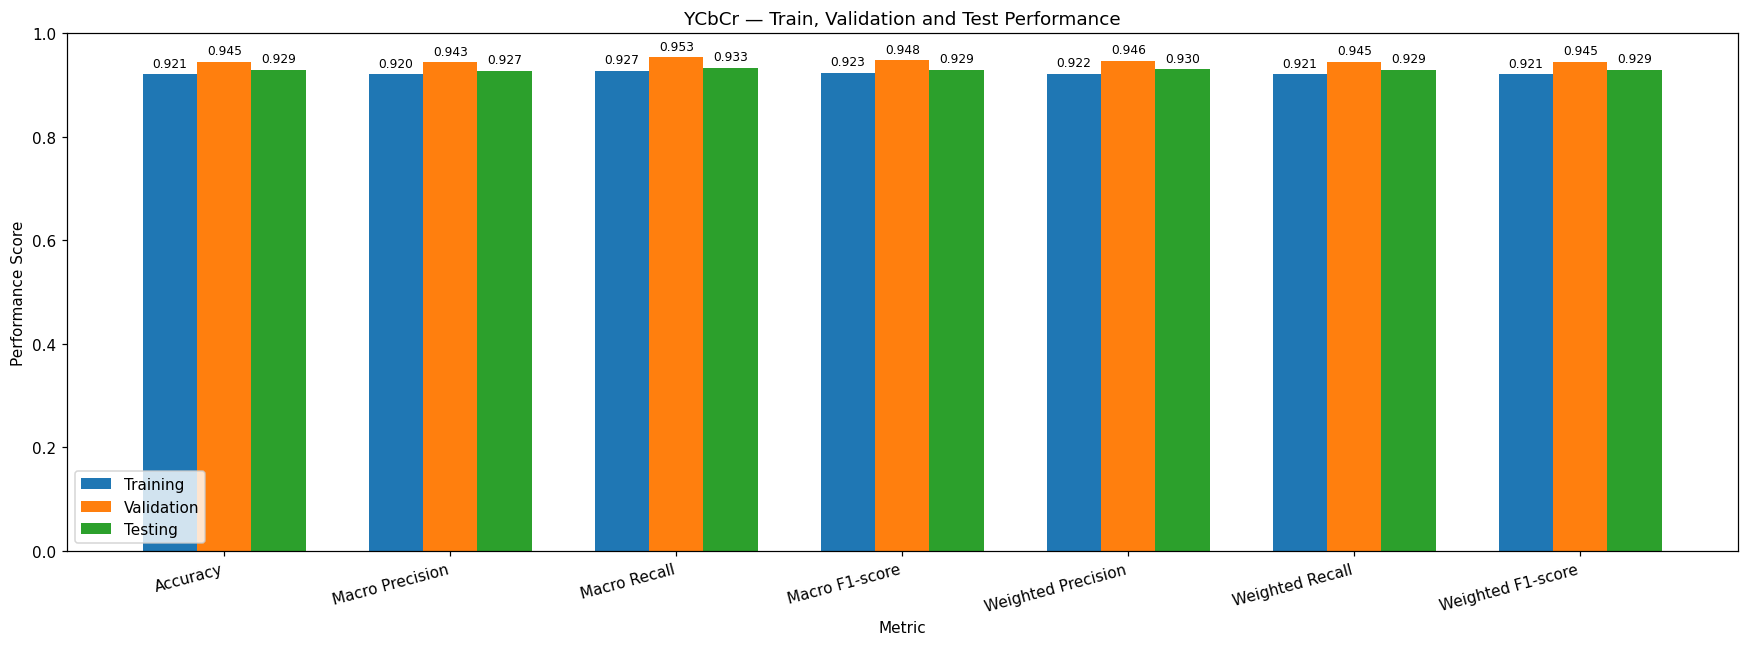

In [13]:
metric_columns = ["Accuracy", "Macro Precision", "Macro Recall", "Macro F1-score",
                  "Weighted Precision", "Weighted Recall", "Weighted F1-score"]
dataset_names = overall_results_table["Dataset"].tolist()
x = np.arange(len(metric_columns))
width = 0.24

fig, ax = plt.subplots(figsize=(16, 6))
for index, dataset_name in enumerate(dataset_names):
    values = overall_results_table.loc[
        overall_results_table["Dataset"] == dataset_name, metric_columns
    ].iloc[0].to_numpy(dtype=float)
    bars = ax.bar(x + (index - 1) * width, values, width, label=dataset_name)
    ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=8)
ax.set_xticks(x, metric_columns, rotation=15, ha="right")
ax.set_ylim(0, 1)
ax.set_xlabel("Metric")
ax.set_ylabel("Performance Score")
ax.set_title("YCbCr — Train, Validation and Test Performance")
ax.legend()
plt.tight_layout()
overall_metric_figure = fig
plt.show()


### 19.6 Per-Class Metric Comparisons


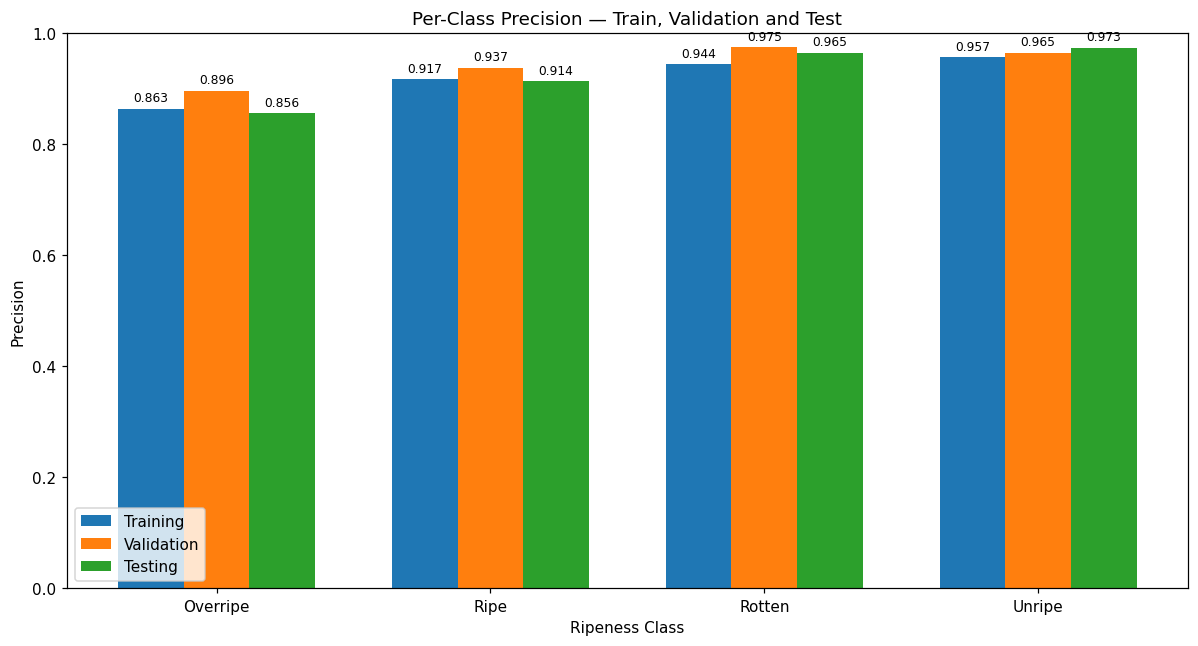

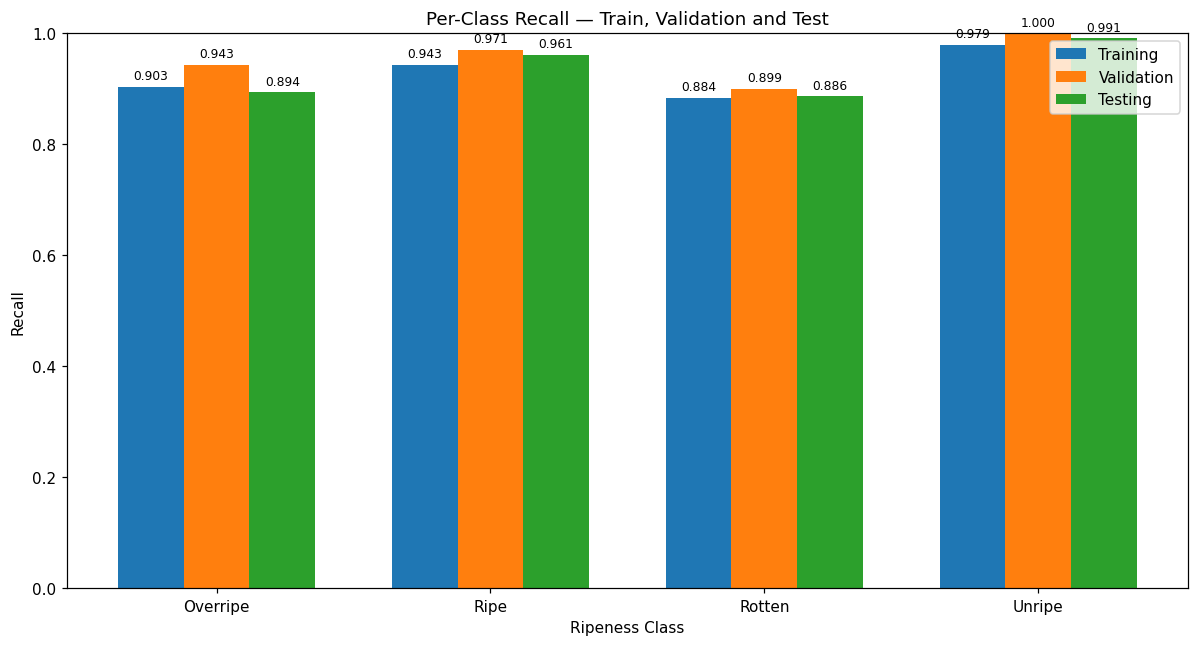

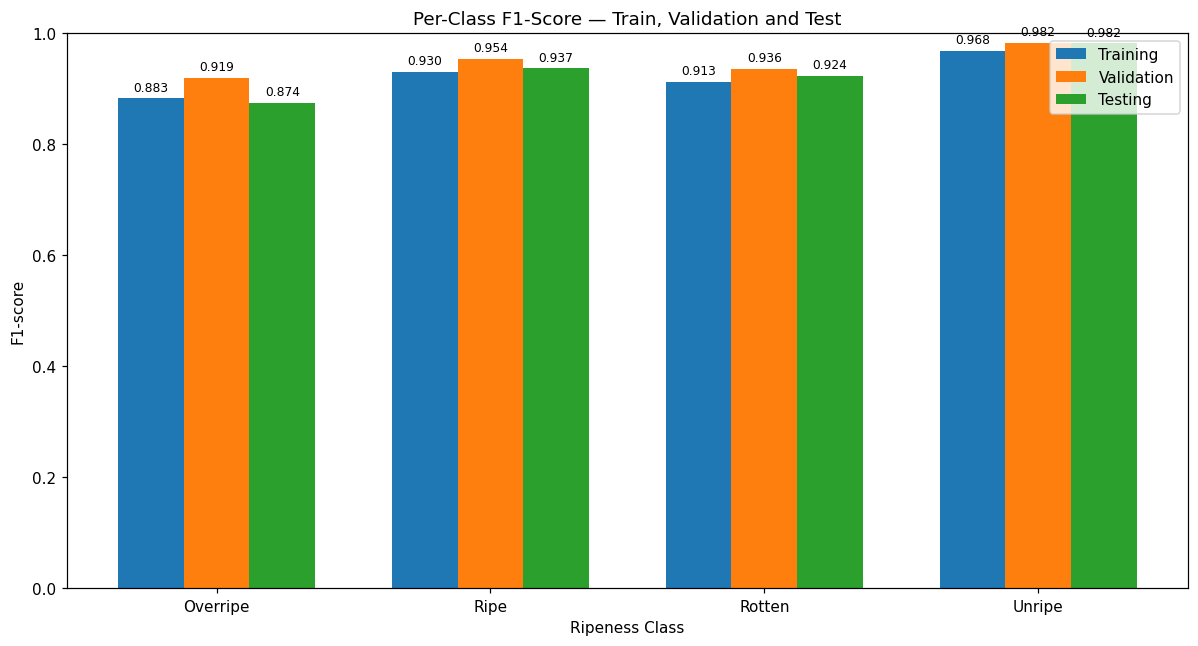

In [14]:
per_class_tables = {
    "Training": training_per_class_table,
    "Validation": validation_per_class_table,
    "Testing": testing_per_class_table,
}
class_labels = [label.capitalize() for label in CLASS_ORDER]
x = np.arange(len(CLASS_ORDER))
width = 0.24

per_class_figures = {}

def plot_per_class_comparison(metric_column, title, y_label):
    fig, ax = plt.subplots(figsize=(11, 6))
    for index, (dataset_name, table) in enumerate(per_class_tables.items()):
        aligned = table.set_index("Class").reindex(CLASS_ORDER)
        values = aligned[metric_column].to_numpy(dtype=float)
        bars = ax.bar(x + (index - 1) * width, values, width, label=dataset_name)
        ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=8)
    ax.set_xticks(x, class_labels)
    ax.set_ylim(0, 1)
    ax.set_xlabel("Ripeness Class")
    ax.set_ylabel(y_label)
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    per_class_figures[metric_column] = fig
    plt.show()

plot_per_class_comparison(
    "Precision", "Per-Class Precision — Train, Validation and Test", "Precision"
)
plot_per_class_comparison(
    "Recall", "Per-Class Recall — Train, Validation and Test", "Recall"
)
plot_per_class_comparison(
    "F1-score", "Per-Class F1-Score — Train, Validation and Test", "F1-score"
)


### 19.7 Confusion Matrices


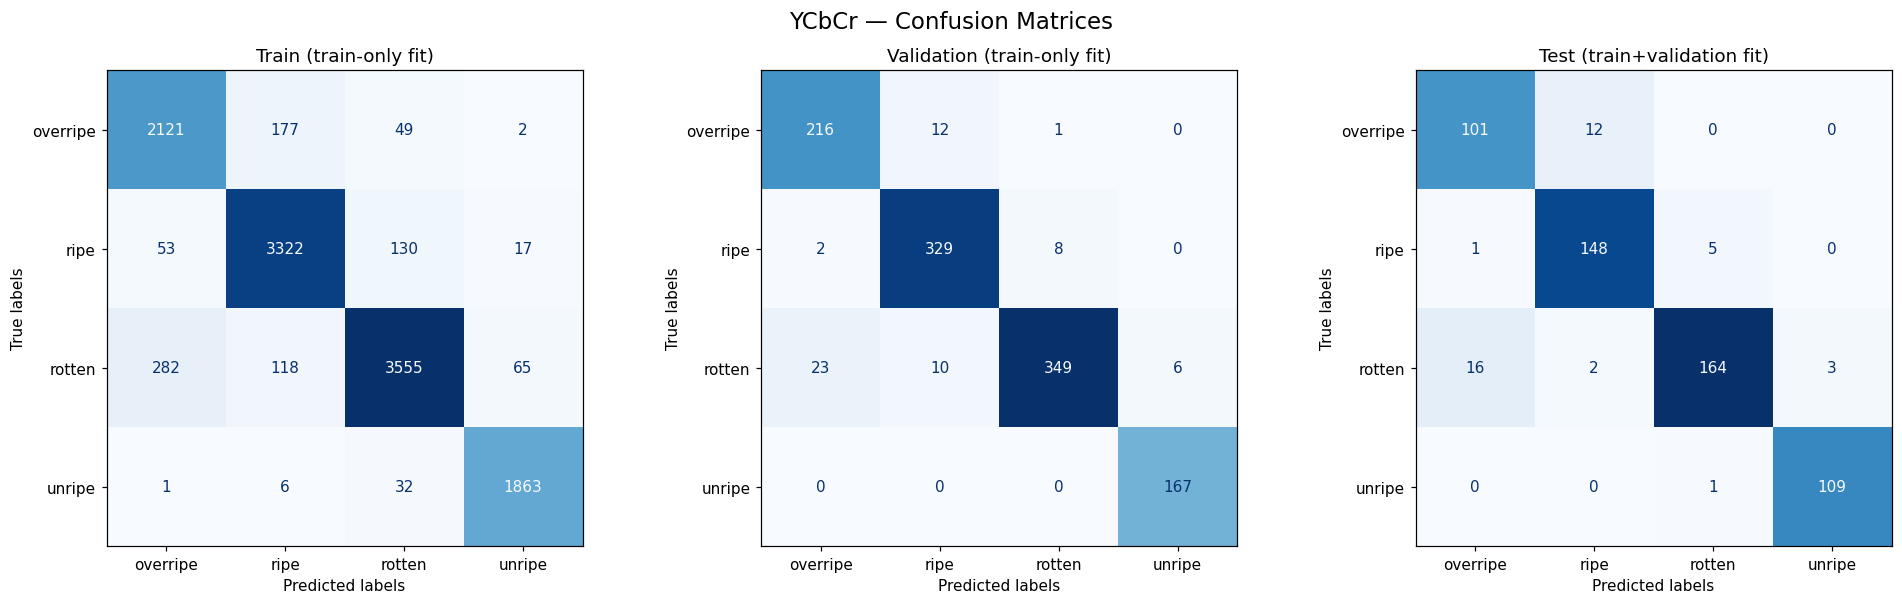

In [15]:
train_cm_complete = confusion_matrix(y_train, train_pred_complete, labels=CLASS_ORDER)
validation_cm_complete = confusion_matrix(y_val, validation_pred_complete, labels=CLASS_ORDER)
testing_cm_complete = confusion_matrix(y_test, testing_pred_complete, labels=CLASS_ORDER)

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
for ax, matrix, title in zip(
    axes,
    [train_cm_complete, validation_cm_complete, testing_cm_complete],
    ["Train (train-only fit)", "Validation (train-only fit)", "Test (train+validation fit)"],
):
    ConfusionMatrixDisplay(matrix, display_labels=CLASS_ORDER).plot(
        ax=ax, cmap="Blues", values_format="d", colorbar=False
    )
    ax.set_title(title)
    ax.set_xlabel("Predicted labels")
    ax.set_ylabel("True labels")
fig.suptitle("YCbCr — Confusion Matrices", fontsize=15)
plt.tight_layout()
confusion_matrices_figure = fig
plt.show()


## 20. Processing Time and Final Results

Processing time is reported separately from classifier training time. The final test metrics summarize the performance of the YCbCr approach.

In [16]:
display(processing_time_table)
# Keep the legacy final-test summary, using the same current predictions.
final_test_metrics, final_cm = evaluate_model(y_test, test_pred)
validation_metrics, validation_cm = evaluate_model(y_val, val_pred)
final_results = pd.DataFrame([
    *[{"Metric": key, "Result": value} for key, value in final_test_metrics.items()],
    {"Metric": "Mean Processing Time per Image", "Result": overall_mean},
    {"Metric": "Total Processing Time", "Result": overall_total},
])
display(final_results)
print("Validation model training time (excluded):", validation_model_training_time)
print("Final model training time (excluded):", final_model_training_time)


Validation model training time (excluded): 2.7536633999989135
Final model training time (excluded): 4.317 seconds (historical rounded notebook value; final model loaded, not refitted)


,Subset,Number of Images,Total Processing Time (seconds),Mean Processing Time (seconds/image),Mean Processing Time (ms/image)
0,Training,11793,121.769974,0.010326,10.325615
1,Validation,1123,11.204949,0.009978,9.977692
2,Testing,562,6.448317,0.011474,11.473874
3,Overall,13478,139.423240,0.010345,10.344505


,Metric,Result
0,Accuracy,0.928826
1,Macro Precision,0.926858
2,Macro Recall,0.933060
3,Macro F1-score,0.929273
4,Weighted Precision,0.930491
5,Weighted Recall,0.928826
6,Weighted F1-score,0.928852
7,Mean Processing Time per Image,0.010345
8,Total Processing Time,139.423240


## 21. Results and Discussion

### 21.1 Classification Performance

The current calculated Training, Validation and Testing metrics are shown in Section 19.4. Training and Validation use the same training-only development model, while Testing uses the fresh model fitted on Training + Validation. Differences between subsets should be interpreted alongside their sample counts and class distributions, without using test performance to adjust the method.

### 21.2 Class-Level Performance

The per-class precision, recall, F1-score and support tables in Sections 19.1–19.3 and the confusion matrices in Section 19.7 show where errors occur. Visually similar later ripeness stages can still be confused: rotten and overripe bananas may both have brown or dark peel, while ripe and overripe bananas can retain yellow peel. Per-class recall is not labelled as per-class accuracy.

### 21.3 Processing Performance

Section 20 reports the actual recorded processing durations for each subset and all 13,478 images. These reuse per-image timings of the existing image-loading, preprocessing and feature-extraction pipeline; classifier fitting, prediction, chart generation and saving are excluded. The Overall mean is total recorded time divided by the total image count.

### 21.4 Overall Interpretation

YCbCr separates luminance from chrominance. Gamma correction is applied only to Y, while Cb and Cr retain peel-colour information for the fixed-range segmentation and normalized histograms. Fixed Cb–Cr ranges may still overlap with some backgrounds, especially those with colours similar to darker peel. The numerical tables and confusion matrices should guide comparisons with other methods without overstating the strengths of YCbCr.


## 22. Saved Outputs

Execute this cell after Sections 19–20. Each execution creates one new `results/ycbcr_YYYYMMDD_HHMMSS` folder using the actual execution time; all outputs share that folder. An existing same-second folder raises an error rather than being overwritten. Previous results remain untouched.

**Rerun guide (1-based notebook cell positions):** if the existing models, predictions, feature matrices, labels and `processed` per-image timings remain in the kernel, rerun cell 34 (evaluation helper / validation), then code cells 40, 41, 43, 45, 47, 49, 51, 53, 55 and 58, in that order. These are Sections 16 and 19–22; they do not fit either model or process the full dataset. Cell 40 only refreshes the legacy training-accuracy variable and may be skipped. No Run All is needed for timing: the existing feature CSVs also preserve exact per-image timings.

Saved notebook outputs do not prove a live kernel still contains variables. If the kernel was restarted, restore the matching cached features, labels, predictions and models before running the evaluation cells. The saved final model must never substitute for the train-only development model. The previous run saved validation/test predictions and the final model, but did not save training predictions or the development model; those require the original live kernel or rebuilding the unchanged development model from cached training features (no image processing).


In [17]:
# Execute this cell once per saving run. Never reuse an earlier results folder.
from datetime import datetime
OUTPUT_ROOT = Path("results")
RUN_TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")
RESULTS_DIR = OUTPUT_ROOT / f"ycbcr_{RUN_TIMESTAMP}"
RESULTS_DIR.mkdir(parents=True, exist_ok=False)

for name, stem, table, matrix in [
    ("Training", "training", training_per_class_table, train_cm_complete),
    ("Validation", "validation", validation_per_class_table, validation_cm_complete),
    ("Testing", "testing", testing_per_class_table, testing_cm_complete),
]:
    overall_results_table.set_index("Dataset").loc[[name]].to_csv(
        RESULTS_DIR / f"{stem}_metrics.csv", index=False)
    table.to_csv(RESULTS_DIR / f"{stem}_per_class_metrics.csv", index=False)
    pd.DataFrame(matrix, index=pd.Index(CLASS_ORDER, name="True Class"),
                 columns=CLASS_ORDER).to_csv(RESULTS_DIR / f"{stem}_confusion_matrix.csv")
overall_results_table.to_csv(RESULTS_DIR / "train_validation_test_metrics.csv", index=False)
processing_time_table.to_csv(RESULTS_DIR / "processing_time.csv", index=False)

# Retained Figure objects remain saveable after inline plt.show().
for figure, filename in [
    (overall_metric_figure, "overall_metric_comparison.png"),
    (per_class_figures["Precision"], "per_class_precision_comparison.png"),
    (per_class_figures["Recall"], "per_class_recall_comparison.png"),
    (per_class_figures["F1-score"], "per_class_f1_comparison.png"),
    (confusion_matrices_figure, "train_validation_test_confusion_matrices.png"),
]:
    figure.savefig(RESULTS_DIR / filename, dpi=300, bbox_inches="tight")
pd.DataFrame({"image_path": processed["train"].image_path,
              "true_class": y_train, "predicted_class": train_pred_complete}).to_csv(
    RESULTS_DIR / "training_predictions.csv", index=False)


dataset_counts.to_csv(RESULTS_DIR / "dataset_counts.csv", index=False)
processed["train"].to_csv(RESULTS_DIR / "train_features.csv", index=False)
processed["validation"].to_csv(RESULTS_DIR / "validation_features.csv", index=False)
processed["test"].to_csv(RESULTS_DIR / "test_features.csv", index=False)

pd.DataFrame({
    "image_path": processed["validation"].image_path,
    "true_class": y_val,
    "predicted_class": val_pred
}).to_csv(RESULTS_DIR / "validation_predictions.csv", index=False)

pd.DataFrame({
    "image_path": processed["test"].image_path,
    "true_class": y_test,
    "predicted_class": test_pred
}).to_csv(RESULTS_DIR / "test_predictions.csv", index=False)

final_results.to_csv(RESULTS_DIR / "final_test_metrics.csv", index=False)
processing_time_summary.to_csv(RESULTS_DIR / "processing_time_summary.csv", index=False)
failed_images.to_csv(RESULTS_DIR / "failed_images.csv", index=False)

joblib.dump(final_model, RESULTS_DIR / "final_scaler_svc_pipeline.joblib")
(RESULTS_DIR / "frozen_parameters.json").write_text(
    json.dumps(frozen_parameters, indent=2), encoding="utf-8"
)

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(final_cm, display_labels=CLASS_ORDER).plot(
    ax=ax, cmap="Blues", values_format="d", colorbar=False
)
ax.set_title("YCbCr Banana Ripeness — Final Test Confusion Matrix")
ax.set_xlabel("Predicted labels"); ax.set_ylabel("True labels")
fig.tight_layout()
fig.savefig(RESULTS_DIR / "confusion_matrix.png", dpi=200, bbox_inches="tight")
plt.close(fig)

fig, axes = plt.subplots(len(CLASS_ORDER), 3, figsize=(12, 14))
column_titles = ["Original Input", "Final Cb–Cr Mask", "Segmented Output"]

for col, title in enumerate(column_titles):
    axes[0, col].set_title(title, fontsize=12, fontweight="bold")

for row, label in enumerate(CLASS_ORDER):
    sample_path = Path(
        image_index.query(
            "subset == 'train' and true_class == @label"
        ).iloc[0]["image_path"]
    )

    original, _, _, _, _, _, _, _, final_mask, segmented = preprocessing_intermediates(sample_path)

    axes[row, 0].imshow(original)
    axes[row, 1].imshow(final_mask, cmap="gray", vmin=0, vmax=255)
    axes[row, 2].imshow(segmented)
    axes[row, 0].set_ylabel(label.capitalize(), fontsize=11, fontweight="bold")

    for col in range(3):
        axes[row, col].axis("off")

fig.suptitle(
    "Sample Input and Output of Final YCbCr Colour Segmentation",
    fontsize=14, fontweight="bold", y=1.01
)
fig.tight_layout()
fig.savefig(
    RESULTS_DIR / "segmentation_examples_all_classes.png",
    dpi=180, bbox_inches="tight"
)
plt.close(fig)

print("Saved outputs to:", RESULTS_DIR.resolve())


Saved outputs to: C:\Users\ASUS\Documents\Banana\results\ycbcr_20260906_004146


## 23. Conclusion and Limitations

The YCbCr method uses a 64-dimensional chrominance histogram representation and the unchanged StandardScaler/default SVC classification protocol. Current calculated results for Training, Validation and Testing are reported in Sections 19–20. Separating luminance from chrominance allows gamma correction on Y while Cb and Cr preserve peel-colour information.

Fixed Cb–Cr ranges may include background regions with similar colours or exclude unusual peel colours. Different lighting conditions, backgrounds, cameras and banana varieties may affect segmentation. Gamma correction cannot recover colour information lost through severe overexposure. Visually similar later ripeness stages, particularly overripe and rotten bananas, remain challenging for colour-based classification.
